# Data Preprocessing

In [22]:
!pip install datasets==3.6.0 transformers evaluate sentencepiece accelerate iterative-stratification pythainlp

In [23]:
# Required for model usage
!pip install transformers sentencepiece -q

# For input preprocessing
!pip install pythainlp emoji -q

# For dataset manipulation
!pip install datasets -q

# For training on GPU
!pip install accelerate -q

# For evaluation
!pip install scikit-learn seqeval -q

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer
import re
import warnings
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorWithPadding
import torch
import evaluate
import torch.nn as nn
from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import f1_score, classification_report
from pythainlp.util import normalize
from transformers import AutoConfig, AutoModelForSequenceClassification
import random

In [25]:
warnings.filterwarnings('ignore')

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## load data

In [27]:
df = pd.read_csv('/content/drive/MyDrive/midterm_dsde/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/midterm_dsde/test.csv')

## clean data

In [28]:
df.isnull().sum()

,0
id,0
comment,2135
สำนักงานตำรวจแห่งชาติ,0
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,0
สภาเด็กและเยาวชนกรุงเทพมหานคร,0
กรมควบคุมมลพิษ,0
กรมสรรพสามิต,0
การไฟฟ้านครหลวง,0
กรมทางหลวง,0
สำนักงานประกันสุขภาพแห่งชาติ,0


In [29]:
pd.set_option('display.max_colwidth', None)
df.iloc[180:186][['comment']]

,comment
180,เริ่มปีใหม่มา ก็เจอรถลูกค้าเพื่อนบ้านร้านพิซซ่าจอดขวางทางเข้าออก/หัวมุมทางเข้าออก ป้ายไม่ช่วยอะไร แถมเพื่อนบ้านอย่างเราต้องไปตาม แถมโดนเถียงกลับจากgrabด้วย
181,ถนน 3 เลน ผิวจราจรไม่เรียบ มีฝาท่อบนถนน ไม่มีเส้นแบ่งเลน
182,ฟุตบาทไม่เรียบและมีการชำรุด \nมีหลุมเป็นช่วงๆ
183,📢🔊 แจ้งป้ายเถื่อน ป้ายกองโจร 😱 ติดป้าย ผิด พรบ.ความสะอาด และความเป็นระเบียบเรียบร้อยของบ้านเมือง❌😤😠🙅‍♀️🙅‍♂️\n🎤โฆษณาด้วยการปิด ทิ้ง หรือ โปรยแผ่นประกาศหรือใบปลิว ในที่สาธารณะ โดยไม่ได้รับอนุญาตมาตรา 10 แห่ง พ.ร.บ.รักษาความสะอาด พ.ศ. ๒๕๓๕\n📸\n📌ตรงสะพานข้ามคลอง\n🛣️ถนน ในซอยรามอินทรา 58\n🙏👷👩‍🔧ขอขอบคุณ เจ้าหน้าที่ทุกท่าน ในการจัดการปัญหานี้✌️✌️💪👏👏👏
184,ไม่แน่ใจสายไฟ หรือสายโทรศัพท์ห้อยระโยงระยางลงมาตรงทางเดินฟุตบาล ปลายสายขาดค่ะ
185,สวัสดีค่ะ \nแจ้งเลยนะคะ เดือดร้อนมากค่ะ ที่บ้านขายของและมีหมาจรมันไปอยู่ที่ข้างบ้านแต่ข้างบ้านเค้าไม่สนใจเค้าบอกเค้าไม่ได้เลี้ยงแต่ให้ข้าวมัน และ เวลาลูกค้ามาซื้อของ เด็กมา มันวิ่งไล่กวด และ จะกระโจนใส่เด็ก ลูกค้าขับมอไซน์มา ก็ วิ่งไล่ค่ะ บางที วิ่งเข้ามาหน้าร้าน ตามลูกค้ามา แจ้งเรื่องทางเขตประเวศมูลนิธิไปแล้ว แต่เงียบเลยค่ะ หลายเดือนแล้ว เลข ที่แจ้ง 1574/66 จะทำไงได้บ้างคะ ถ้ามันกัดมาเค้าบอกแล้วว่าเค้าไม่รับผิดชอบ แล้ว เราจะต้องมารับผิดชอบหรอคะ ที่เราเป็นร้านค้า และมาโดนกัดบริเวณหน้าร้านเรา แบบนี้ลูกค้าก็หายหมดสิคะ แค่ แม่เข็นเด็กรถเข็นมาก็จะพุ่งเข้าใส่รถเข็น ไม่ตายหรอคะ ตั้ง 3 ตัว


In [30]:
pd.reset_option('display.max_colwidth')

In [31]:
# drop missing value
df = df.dropna()

In [32]:
from typing import Collection, Callable
import re
import html
import emoji
from pythainlp.tokenize import word_tokenize

_TK_UNK, _TK_REP, _TK_WREP, _TK_URL, _TK_END = "<unk> <rep> <wrep> <url> </s>".split()

SPACE_SPECIAL_TOKEN = "<_>"

# str->str rules
def fix_html(text: str) -> str:
    re1 = re.compile(r"  +")
    text = (
        text.replace("#39;", "'")
        .replace("amp;", "&")
        .replace("#146;", "'")
        .replace("nbsp;", " ")
        .replace("#36;", "$")
        .replace("\\n", "\n")
        .replace("quot;", "'")
        .replace("<br />", "\n")
        .replace('\\"', '"')
        .replace(" @.@ ", ".")
        .replace(" @-@ ", "-")
        .replace(" @,@ ", ",")
        .replace("\\", " \\ ")
    )
    return re1.sub(" ", html.unescape(text))

def replace_url(text: str) -> str:
    URL_PATTERN = r"(http|ftp|https)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-])?"
    return re.sub(URL_PATTERN, _TK_URL, text)

def rm_brackets(text: str) -> str:
    # remove empty brackets
    new_line = re.sub(r"\(\)", "", text)
    new_line = re.sub(r"\{\}", "", new_line)
    new_line = re.sub(r"\[\]", "", new_line)
    # brakets with only punctuations
    new_line = re.sub(r"\([^a-zA-Z0-9ก-๙]+\)", "", new_line)
    new_line = re.sub(r"\{[^a-zA-Z0-9ก-๙]+\}", "", new_line)
    new_line = re.sub(r"\[[^a-zA-Z0-9ก-๙]+\]", "", new_line)
    # artifiacts after (
    new_line = re.sub(r"(?<=\()[^a-zA-Z0-9ก-๙]+(?=[a-zA-Z0-9ก-๙])", "", new_line)
    new_line = re.sub(r"(?<=\{)[^a-zA-Z0-9ก-๙]+(?=[a-zA-Z0-9ก-๙])", "", new_line)
    new_line = re.sub(r"(?<=\[)[^a-zA-Z0-9ก-๙]+(?=[a-zA-Z0-9ก-๙])", "", new_line)
    # artifacts before )
    new_line = re.sub(r"(?<=[a-zA-Z0-9ก-๙])[^a-zA-Z0-9ก-๙]+(?=\))", "", new_line)
    new_line = re.sub(r"(?<=[a-zA-Z0-9ก-๙])[^a-zA-Z0-9ก-๙]+(?=\})", "", new_line)
    new_line = re.sub(r"(?<=[a-zA-Z0-9ก-๙])[^a-zA-Z0-9ก-๙]+(?=\])", "", new_line)
    return new_line

def replace_newlines(text: str) -> str:

    return re.sub(r"[\n]", " ", text.strip())

def rm_useless_spaces(text: str) -> str:
    return re.sub(" {2,}", " ", text)

def replace_spaces(text: str, space_token: str = SPACE_SPECIAL_TOKEN) -> str:
    return re.sub(" ", space_token, text)

def replace_rep_after(text: str) -> str:

    def _replace_rep(m):
        c, cc = m.groups()
        return f"{c}"

    re_rep = re.compile(r"(\S)(\1{3,})")
    return re_rep.sub(_replace_rep, text)

# List[str] -> List[str] rules
def ungroup_emoji(toks: Collection[str]) -> Collection[str]:
    res = []
    for tok in toks:
        if emoji.emoji_count(tok) == len(tok):
            res.extend(list(tok))
        else:
            res.append(tok)
    return res

def replace_wrep_post(toks: Collection[str]) -> Collection[str]:
    previous_word = None
    rep_count = 0
    res = []
    for current_word in toks + [_TK_END]:
        if current_word == previous_word:
            rep_count += 1
        elif (current_word != previous_word) & (rep_count > 0):
            res += [previous_word]
            rep_count = 0
        else:
            res.append(previous_word)
        previous_word = current_word
    return res[1:]

def remove_space(toks: Collection[str]) -> Collection[str]:
    res = []
    for t in toks:
        t = t.strip()
        if t:
            res.append(t)
    return res

# combine them together
def process_transformers(
    text: str,
    pre_rules: Collection[Callable] = [
        fix_html,
        rm_brackets,
        replace_newlines,
        rm_useless_spaces,
        replace_spaces,
        replace_rep_after,
    ],
    tok_func: Callable = word_tokenize,
    post_rules: Collection[Callable] = [ungroup_emoji, replace_wrep_post],
) -> str:
    text = text.lower()
    for rule in pre_rules:
        text = rule(text)
    toks = tok_func(text)
    for rule in post_rules:
        toks = rule(toks)
    return "".join(toks)

In [33]:
df = df.dropna(subset=['comment'])

In [34]:
df['comment'] = df['comment'].astype(str).apply(process_transformers)
df_test['comment'] = df_test['comment'].astype(str).apply(process_transformers)

In [35]:
def clean_pipeline(data) :
    # remove id
    data.drop(columns=['id'], inplace=True)
    # drop duplicate
    data = data.drop_duplicates()
    # remove comment that len=1
    data = data[data['comment'].astype(str).str.strip().str.len() > 1]
    # remove emoji, unwanted sign (keep only ก-ฮ, a-z, 0-9, ช่องว่าง)
    data['comment'] = data['comment'].astype(str).apply(
        lambda x: re.sub(r'[^ก-๙a-zA-Z0-9\s]', ' ', x)
    )
    data = data.reset_index(drop=True) # reset index ใหม่ ให้เรียงกัน ไม่มีตัวไหนถูกข้าม

    return data

In [36]:
df = clean_pipeline(df)

In [37]:
# Normalization
def clean_and_filter(text):
    if not isinstance(text, str): return ""

    # Normalize สระลอย/วรรณยุกต์
    text = normalize(text)

    # ลดตัวอักษรซ้ำเกิน 2 ตัว (เช่น มากกกก -> มากก)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # ลบช่องว่างซ้ำซ้อน
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['comment'] = df['comment'].apply(clean_and_filter)
df_test['comment'] = df_test['comment'].apply(clean_and_filter)

# lenght-filter clean ข้อมูล outlier ออก (train set only)
min_len = 5
max_len = 1000

df = df[df['comment'].str.len().between(min_len, max_len)]

df = df.reset_index(drop=True)

In [38]:
def clean_test_pipeline(data):
    data['comment'] = data['comment'].fillna(' ')

    data['comment'] = data['comment'].astype(str).apply(
        lambda x: re.sub(r'[^ก-๙a-zA-Z0-9\s]', ' ', x)
    )

    return data

df_test = clean_test_pipeline(df_test)

In [39]:
df_test.shape

(37406, 2)

In [40]:
df.isnull().sum()

,0
comment,0
สำนักงานตำรวจแห่งชาติ,0
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,0
สภาเด็กและเยาวชนกรุงเทพมหานคร,0
กรมควบคุมมลพิษ,0
กรมสรรพสามิต,0
การไฟฟ้านครหลวง,0
กรมทางหลวง,0
สำนักงานประกันสุขภาพแห่งชาติ,0
การประปานครหลวง,0


In [41]:
df.head()

,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว,0,0,0,0,0,0,0,0,0,0,0,0
1,แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...,0,0,0,0,0,0,0,0,0,0,0,0
2,คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง ส่ง...,0,0,0,0,0,0,0,0,0,0,0,0
3,ไม่แน่ใจ กทม อนุญาตให้ร้านชอคโกแลตวิลจุพลุถึงก...,0,0,0,0,0,0,0,0,0,0,0,0
4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...,0,0,0,0,0,0,0,0,0,0,0,0


In [42]:
pd.set_option('display.max_colwidth', None)
df.iloc[180:186][['comment']]

,comment
180,แจ้งป้ายเถื่อน ป้ายกองโจร ติดป้าย ผิด พรบ ความสะอาด และความเป็นระเบียบเรียบร้อยของบ้านเมือง โฆษณาด้วยการปิด ทิ้ง หรือ โปรยแผ่นประกาศหรือใบปลิว ในที่สาธารณะ โดยไม่ได้รับอนุญาตมาตรา 10 แห่ง พ ร บ รักษาความสะอาด พ ศ ๒๕๓๕ ตรงรามอินทรา 58 แยก 5 ถนน ในซอยรามอินทรา 58 ขอขอบคุณ เจ้าหน้าที่ทุกท่าน ในการจัดการปัญหานี้
181,31 12 66 แยกประชานุกูล ไฟแดงชำรุดอีกแล้ว สจส ซ่อมด้วยครับ
182,แจ้งป้ายเถื่อน ป้ายกองโจร ติดป้าย ผิด พรบ ความสะอาด และความเป็นระเบียบเรียบร้อยของบ้านเมือง โฆษณาด้วยการปิด ทิ้ง หรือ โปรยแผ่นประกาศหรือใบปลิว ในที่สาธารณะ โดยไม่ได้รับอนุญาตมาตรา 10 แห่ง พ ร บ รักษาความสะอาด พ ศ ๒๕๓๕ ตรง เพริศพราย เพลส ถนน ในซอยรามอินทรา 58 ขอขอบคุณ เจ้าหน้าที่ทุกท่าน ในการจัดการปัญหานี้
183,ไม่มีถังขยะ คนทิ้งขยะเกลื่อนทางเดิน
184,สถานที่ตั้งเหมือนโรงงานขนาดเล็ก มีการเผาอะไรไม่ทราบ แล้วต่อท่อปล่องควัน ปล่อยควันออกไปทางชั้น 4 ส่วนชั้น 5 ต่อเติมเป็นห้องเผาขยะ ควันจากการเผาทั้งสองช่องทาง ลอยเข้าบ้าน โดยเฉพาะห้องนอนชั้นบนทุกครั้ง รบกวนการใช้ชีวิต เหม็นจนแสบจมูกและเวียนหัว
185,คนเช็ดกระจกตามแยกไฟแดง


In [43]:
pd.reset_option('display.max_colwidth')

In [44]:
target_columns = ['สำนักงานตำรวจแห่งชาติ',
       'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย', 'สภาเด็กและเยาวชนกรุงเทพมหานคร',
       'กรมควบคุมมลพิษ', 'กรมสรรพสามิต', 'การไฟฟ้านครหลวง', 'กรมทางหลวง',
       'สำนักงานประกันสุขภาพแห่งชาติ', 'การประปานครหลวง',
       'คณะกรรมการการพัฒนาเศรษฐกิจ', 'กระทรวงการท่องเที่ยวและกีฬา',
       'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200']

df['labels'] = df[target_columns].values.tolist() # แปลงเปน comment, [0,0,...,0] (labels)
df['labels'] = df['labels'].apply(lambda x: [float(i) for i in x]) # แปลงเปน float

In [45]:
df.to_csv("/content/drive/MyDrive/midterm_dsde/prepared_data.csv", index=False)

## PhayaThaiBERT

In [46]:
rare_keywords = {
    'สภาเด็กและเยาวชนกรุงเทพมหานคร': ['เด็ก', 'เยาวชน', 'ขอทาน'],
    'สำนักงานประกันสุขภาพแห่งชาติ': ['สาธารณสุข', 'เวชกรรม', 'การรักษา', 'คลินิก','คลีนิค'],
    'คณะกรรมการการพัฒนาเศรษฐกิจ': ['เว็บโป๊', 'เศรษฐกิจ', 'ไซต์งานก่อสร้าง'],
    'กระทรวงการท่องเที่ยวและกีฬา': ['จุดพลุ', 'การจัดงาน', 'website english', 'พลุ']
}

In [47]:
# split train 80% test 20% with stratify from sampling
df['stratify_key'] = df[target_columns].apply(lambda x: ''.join(x.astype(str)), axis=1)
key_counts = df['stratify_key'].value_counts()
rare_keys = key_counts[key_counts == 1].index # pattern ที่มีแค่ 1 ตัวอย่าง ทำให้แบ่ง stratify ไม่ได้
df_rare = df[df['stratify_key'].isin(rare_keys)]
df_common = df[~df['stratify_key'].isin(rare_keys)]

train_common, test_df = train_test_split(df_common, test_size=0.2, random_state=42, stratify=df_common['stratify_key'])

train_df = pd.concat([train_common, df_rare], axis=0).reset_index(drop=True) # เอา rare case ไว้ฝั่ง train

train_df = train_df.drop(columns=['stratify_key'])
test_df = test_df.drop(columns=['stratify_key'])
df.drop(columns=['stratify_key'], inplace=True)

final_df_list = []
upper_bound = 25000
lower_bound = 1500

processed_indices = set()

# เรียงลำดับคลาสจาก น้อย ไป มาก เพื่อให้ความสำคัญกับ Rare Classes ก่อน
sorted_columns = train_df[target_columns].sum().sort_values().index

for col in sorted_columns:
    class_data = train_df[train_df[col] == 1]

    unique_class_data = class_data[~class_data.index.isin(processed_indices)]

    class_size = len(class_data)
    if class_size == 0: continue

    if class_size > upper_bound:
        sampled = class_data.sample(n=upper_bound, random_state=42)
        final_df_list.append(sampled)
    elif class_size < lower_bound:
        repeat_factor = (lower_bound // class_size)
        temp_list = [class_data]
        for i in range(repeat_factor - 1):
            augmented_subset = class_data.copy()
            if col in rare_keywords:
                augmented_subset['comment'] = augmented_subset['comment'].apply(
                    lambda x: f"{x} {random.choice(rare_keywords[col])}"
                )
            temp_list.append(augmented_subset)
        final_df_list.append(pd.concat(temp_list, ignore_index=True))
    else:
        final_df_list.append(class_data)

    # อัปเดต indices ที่ใช้ไปแล้ว
    processed_indices.update(class_data.index)

train_df = pd.concat(final_df_list).reset_index(drop=True)

# check
print(f"Total rows: {len(train_df)}")
print(f"Unique comments: {train_df['comment'].nunique()}")

Total rows: 62254
Unique comments: 53590


In [48]:
train_df[target_columns].sum()

,0
สำนักงานตำรวจแห่งชาติ,26369
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,2365
สภาเด็กและเยาวชนกรุงเทพมหานคร,1508
กรมควบคุมมลพิษ,1739
กรมสรรพสามิต,1485
การไฟฟ้านครหลวง,16230
กรมทางหลวง,6359
สำนักงานประกันสุขภาพแห่งชาติ,1487
การประปานครหลวง,2453
คณะกรรมการการพัฒนาเศรษฐกิจ,1503


In [49]:
dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'test': Dataset.from_pandas(test_df)
})

In [50]:
model_path = "clicknext/phayathaibert"
tokenizer = AutoTokenizer.from_pretrained(model_path)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.26M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.4M [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

In [51]:
# # คำนวณว่าถ้าตัดที่ 256 tokens จะมีกี่ % ของข้อมูลที่โดนตัด
# token_counts = [len(tokenizer.encode(text)) for text in df['comment']]
# lost_data_ratio = np.mean([1 if c > 256 else 0 for c in token_counts]) * 100

# print(f"มีข้อมูลเพียง {lost_data_ratio:.2f}% เท่านั้นที่จะถูกตัดบางส่วนทิ้ง")

In [52]:
def preprocess_function(ex):
    return tokenizer(
        ex["comment"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

tokenized_dataset = dataset.map(preprocess_function, batched=True) # ใส่ batched=True เพื่อให้เรวขึ้น โดยส่งเปน batch แล้วประมวลผลแบบ parallel ทีเดียว ไม่ใช่ประมวลผลทีละ comment

Map:   0%|          | 0/62254 [00:00<?, ? examples/s]

Map:   0%|          | 0/54038 [00:00<?, ? examples/s]

In [53]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [54]:
# for test
test_dataset = Dataset.from_pandas(df_test)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/37406 [00:00<?, ? examples/s]

matric

In [55]:
# Combine metrics with averaging methods for multilabel
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
epoch_f1_history = []

# อย่าลืม tune threshold และ ทุก class ไม่จำเปนต้องใช้ threshold เดียวกัน

def sigmoid(x): # แปลงให้อยู่ในช่วง 0-1
    return 1 / (1 + np.exp(-x))

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Apply sigmoid to raw logits
    probs = sigmoid(predictions)

    # Apply Threshold
    y_pred = (probs > 0.5).astype(int).reshape(-1)
    y_true = labels.astype(int).reshape(-1)

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    # array ขนาดเท่าจน.class
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    epoch_f1_history.append(per_class_f1)

    return {
        "macro_f1": macro_f1
    }

model

In [56]:
class2id = {class_:id for id, class_ in enumerate(target_columns)}
id2class = {id:class_ for class_, id in class2id.items()}

config = AutoConfig.from_pretrained(
    model_path,
    num_labels=len(target_columns),
    id2label=id2class,
    label2id=class2id,
    problem_type="multi_label_classification"
)

# ไม่ให้ model พึ่งพา neuron ตัวใดตัวหนึ่งมากเกินไป
config.hidden_dropout_prob = 0.3 # สุ่มปิด neuron ใน layer ปกติ
config.attention_probs_dropout_prob = 0.3 # สุ่มปิด connection ใน attention mechanism

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    config=config
)

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: clicknext/phayathaibert
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Steps

In [57]:
class_counts = train_df[target_columns].sum(axis=0)
total_samples = len(train_df)
pos_weights = total_samples / (len(target_columns) * class_counts)

# ส่งไป GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weights_tensor = torch.tensor(pos_weights.values, dtype=torch.float32).to(device)

In [58]:
class WeightedMultiLabelTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # self.class_weights = class_weights.to(self.model.device) # ส่ง parameter นี้เพิ่ม
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weights = self.class_weights.to(logits.device)
        # ใช้ pos_weight เพื่อแก้ปัญหา imbalance
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=weights)
        loss = loss_fct(logits, labels.float())

        return (loss, outputs) if return_outputs else loss

In [59]:
import random
import os

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True # ทำให้การคำนวณบน GPU คงที่
    torch.backends.cudnn.benchmark = False

# เรียกใช้งาน
set_seed(42)

In [60]:
report_to = "wandb"

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/midterm_dsde/full_version",
    seed=42,
    data_seed=42,
    learning_rate=2e-5,
    lr_scheduler_type="cosine", # ค่อยๆลด learning rate ลงเปนกราฟ cosine
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    label_smoothing_factor=0.05,
    warmup_steps= 500,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    load_best_model_at_end=True,
    report_to="none",
    fp16=True,
)

In [61]:
%%time
trainer = WeightedMultiLabelTrainer(
    class_weights=pos_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)] # ใส่ earlystopping
)
print(len(trainer.train_dataset))
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 6, 'bos_token_id': 5}.


62254


Epoch,Training Loss,Validation Loss,Macro F1
1,0.192084,0.144470,0.678164
2,0.148418,0.149714,0.670643


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

CPU times: user 21min 25s, sys: 11.6 s, total: 21min 37s
Wall time: 22min 39s


TrainOutput(global_step=3892, training_loss=0.24813145307205686, metrics={'train_runtime': 1358.7214, 'train_samples_per_second': 229.09, 'train_steps_per_second': 7.161, 'total_flos': 8190593154478080.0, 'train_loss': 0.24813145307205686, 'epoch': 2.0})

In [62]:
epoch_f1_history

[array([0.9725475 , 0.38377958]), array([0.96964127, 0.37164559])]

In [63]:
model_path = "/content/drive/MyDrive/midterm_dsde/full_version"

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/midterm_dsde/full_version/tokenizer_config.json',
 '/content/drive/MyDrive/midterm_dsde/full_version/tokenizer.json')

Evaluation

In [64]:
# Get predictions on test set
preds_output = trainer.predict(tokenized_dataset['test'])

# Apply sigmoid to logits
probs = torch.sigmoid(torch.tensor(preds_output.predictions)).numpy()

# Get ground truth labels
y_true = preds_output.label_ids.astype(int)

In [65]:
best_thresholds = []
default_threshold_for_rare = 0.7

for i in range(y_true.shape[1]):
    best_f1 = 0
    best_thresh = 0.5
    for thresh in np.arange(0.1, 0.9, 0.01):
        y_pred = (probs[:, i] >= thresh).astype(int)
        score = f1_score(y_true[:, i], y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
    best_thresholds.append(best_thresh)

print("Optimization Complete!")

Optimization Complete!


In [66]:
print(best_thresholds)

[np.float64(0.8699999999999996), np.float64(0.7799999999999997), np.float64(0.7299999999999996), np.float64(0.8899999999999996), np.float64(0.8899999999999996), np.float64(0.8799999999999996), np.float64(0.44999999999999984), np.float64(0.8899999999999996), np.float64(0.8899999999999996), np.float64(0.8899999999999996), np.float64(0.8199999999999996), np.float64(0.8899999999999996)]


In [67]:
# Apply threshold
y_pred = (probs > np.array(best_thresholds)).astype(int)

In [68]:
report = classification_report(
    y_true,
    y_pred,
    target_names=target_columns,
    zero_division=0
)
print(report)

                                       precision    recall  f1-score   support

                สำนักงานตำรวจแห่งชาติ       0.47      0.78      0.58      6348
    การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย       0.33      0.31      0.32       497
        สภาเด็กและเยาวชนกรุงเทพมหานคร       0.02      0.50      0.05         6
                       กรมควบคุมมลพิษ       0.08      0.64      0.14       374
                         กรมสรรพสามิต       0.13      0.88      0.23         8
                      การไฟฟ้านครหลวง       0.56      0.65      0.60      3735
                           กรมทางหลวง       0.09      0.40      0.15      1411
         สำนักงานประกันสุขภาพแห่งชาติ       0.04      0.54      0.08        13
                      การประปานครหลวง       0.25      0.58      0.35       565
           คณะกรรมการการพัฒนาเศรษฐกิจ       0.04      0.20      0.06         5
          กระทรวงการท่องเที่ยวและกีฬา       0.11      0.62      0.19         8
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200       0.58   

# Apply with given test.csv

In [69]:
pred_test = trainer.predict(tokenized_test)

In [70]:
pred_test

PredictionOutput(predictions=array([[ 0.6699219, -2.4179688, -6.4257812, ..., -6.8710938, -6.5859375,
        -6.1210938],
       [-4.96875  , -2.6757812, -5.328125 , ..., -4.8789062, -4.9609375,
        -2.8066406],
       [-4.9414062, -1.0292969, -6.125    , ..., -6.1484375, -6.7578125,
        -4.3398438],
       ...,
       [-5.6367188, -4.9609375, -5.5546875, ..., -5.7148438, -6.4804688,
        -4.7773438],
       [ 2.9082031, -5.328125 , -6.0039062, ..., -6.7851562, -5.9882812,
        -6.125    ],
       [-2.2285156, -2.0429688, -6.5      , ..., -6.78125  , -7.0546875,
        -4.9140625]], dtype=float32), label_ids=None, metrics={'test_runtime': 76.3299, 'test_samples_per_second': 490.057, 'test_steps_per_second': 30.63})

In [71]:
# Apply sigmoid to logits
test_probs = torch.sigmoid(torch.tensor(pred_test.predictions)).numpy()

# Apply threshold
y_test_pred = (test_probs > np.array(best_thresholds)).astype(int)

# Save to submission

In [72]:
submission_df = pd.DataFrame(y_test_pred, columns=target_columns)

In [73]:
submission_df

,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
37401,0,0,0,0,0,0,0,0,0,0,0,0
37402,0,0,0,0,0,0,0,0,0,0,0,0
37403,0,0,0,0,0,1,0,0,0,0,0,0
37404,1,0,0,0,0,0,0,0,0,0,0,0


In [74]:
submission_df.columns

Index(['สำนักงานตำรวจแห่งชาติ', 'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย',
       'สภาเด็กและเยาวชนกรุงเทพมหานคร', 'กรมควบคุมมลพิษ', 'กรมสรรพสามิต',
       'การไฟฟ้านครหลวง', 'กรมทางหลวง', 'สำนักงานประกันสุขภาพแห่งชาติ',
       'การประปานครหลวง', 'คณะกรรมการการพัฒนาเศรษฐกิจ',
       'กระทรวงการท่องเที่ยวและกีฬา', 'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200'],
      dtype='object')

In [75]:
submission_df.insert(0, 'id', submission_df.index)

In [76]:
submission_df.columns

Index(['id', 'สำนักงานตำรวจแห่งชาติ', 'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย',
       'สภาเด็กและเยาวชนกรุงเทพมหานคร', 'กรมควบคุมมลพิษ', 'กรมสรรพสามิต',
       'การไฟฟ้านครหลวง', 'กรมทางหลวง', 'สำนักงานประกันสุขภาพแห่งชาติ',
       'การประปานครหลวง', 'คณะกรรมการการพัฒนาเศรษฐกิจ',
       'กระทรวงการท่องเที่ยวและกีฬา', 'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200'],
      dtype='object')

In [77]:
submission_df.head(1)

,id,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [79]:
save_path = '/content/drive/MyDrive/midterm_dsde/submission.csv'
# save_path = '/kaggle/working/submission1.csv'
submission_df.to_csv(save_path, index=False, encoding='utf-8-sig')
print('done!')

done!


## error analysis

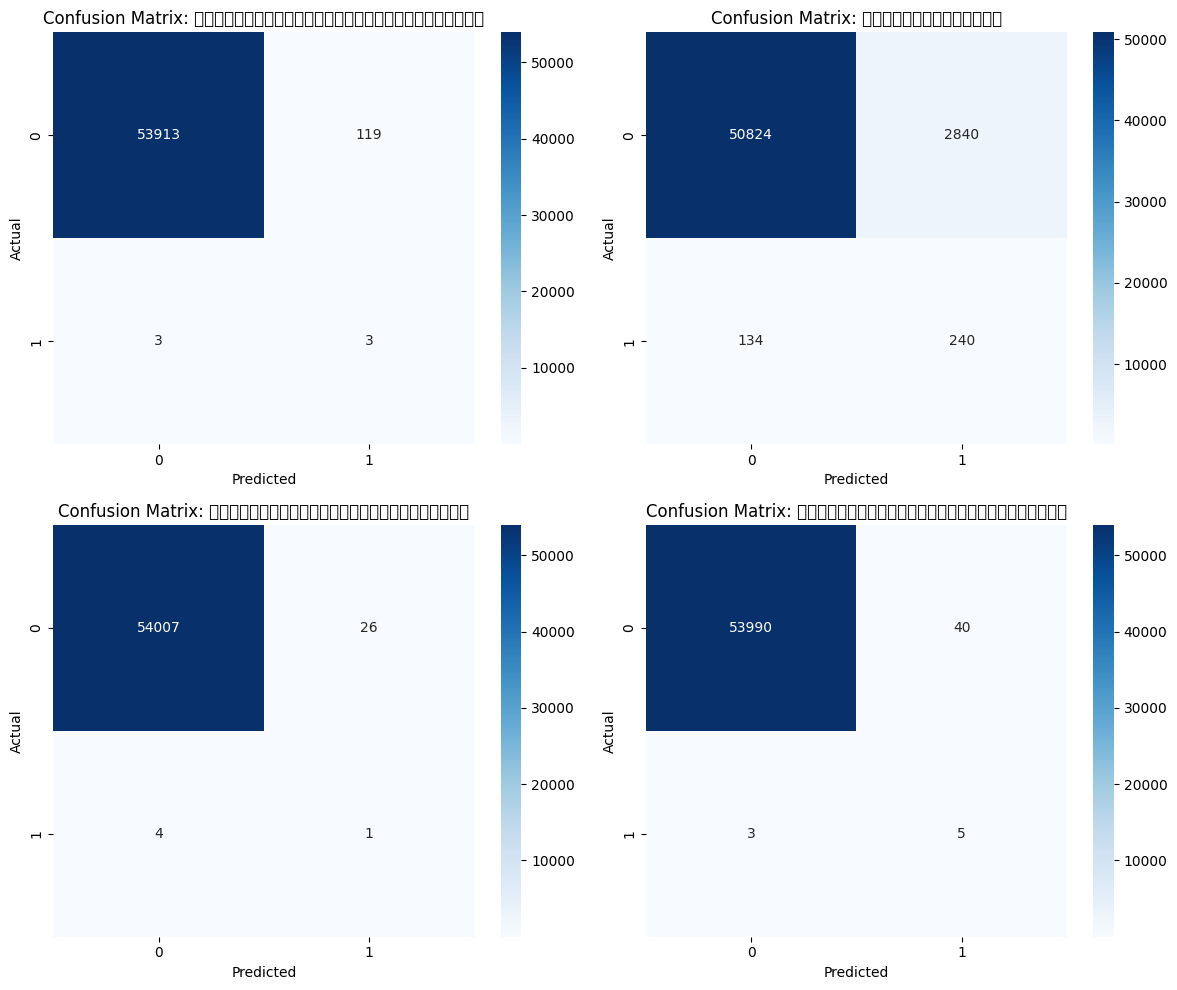

In [81]:
# Confusion Matrix
mcm = multilabel_confusion_matrix(y_true, y_pred)

target_idx = [2, 3, 9, 10] # class ที่ค่าแปลกและอยากวิเคราะห์
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

for i, ax in zip(target_idx, axes.flatten()):
    sns.heatmap(mcm[i], annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {target_columns[i]}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [80]:
rare_class_name = 'สภาเด็กและเยาวชนกรุงเทพมหานคร'
samples = df[df[rare_class_name] == 1]['comment'].head(10).values
for i, s in enumerate(samples):
    print(f"{i+1}: {s}")

1: ต้องการแจ้งปัญหาเรื่องนกพิราบที่เข้ามาอยู่อาศัยภายในหมู่บ้านเป็นจำนวนมาก และอยู่ในบริเวณกว้าง ภายในหมู่บ้านค่ะ
2: การขนย้ายวัสดุก่อสร้างส่วเสียงดังและสั่นสะเทือนบ้านก่อความรำคาญ
3: ตรงช่วงบ้านร้างของสวนสาธาณะริมบึงแก้มลิงของ กทม ท้ายซอยนวมินทร์24 แยกอุเทน 18 20 ช่วงเย็นบ่าย เย็นของเกือบทุกวัน มีกลุ่มวัยรุ่นเด็กๆ ทั้งขี่มอเตอร์ไซด์เข้ามาจอดรถรวมกัน มาสูบบุหรี่ ทิ้งขยะ ฯลฯ มานั่งรวมกลุ่ม มั่วสุม สร้างความรำคาญแก่คนวิ่ง เดิน ออกกำลังกาย อยากให้มี รปภ มาประจำฝั่งสวนใหม่ด้านนี้บ้าง จะได้ไม่เป็นแหล่งมั่วสุมใหม่ค่ะ ขอบคุณค่ะ
4: ถนนเป็นหลุมตื้นวงกว้าง เด็กและเยาวชนอาจได้รับอันตราย
5: เด็กและผู้ปกครองได้รับความเดือดร้อนจากโรงงานนี้ ทั้งเสียงดัง ทั้งมีฝุ่นมี แรงสั่นสะเทือนต่อเนื่องมาหลายเดือน เด็กไม่สามารถพักผ่อนได้ ป่วยโควิดก็พักผ่อนไม่ได้ เดือดร้อนมากๆมีหน่วยงานราชการสำนักงานเขตสะพานสูงก็ไม่สามารถดำเนินการให้หยุดได้
6: มีขอทานพาเด็กมานอนตรงใต้สะพานทางลงบีทีเอสอโศกฝั่งโรบินสันรบกวนดูแลให้เด็กได้ไปใช้ชีวิตแบบเด็กหน่อยนะคะ
7: เจอน้องเด็กผู้ชายกับพ่อมานั่งวาดรูปแผ่นละ 1 บาท ริมถนน ข้างเซเว่นซอย

In [82]:
for i, class_name in enumerate(target_columns):
    tn, fp, fn, tp = mcm[i].ravel()
    print(f"Class: {class_name}")
    print(f"  Precision: {tp/(tp+fp):.2f} | Recall: {tp/(tp+fn):.2f}")
    print(f"  Missed (FN): {fn} | Wrongly Flagged (FP): {fp}\n")

Class: สำนักงานตำรวจแห่งชาติ
  Precision: 0.47 | Recall: 0.78
  Missed (FN): 1395 | Wrongly Flagged (FP): 5675

Class: การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย
  Precision: 0.33 | Recall: 0.31
  Missed (FN): 344 | Wrongly Flagged (FP): 306

Class: สภาเด็กและเยาวชนกรุงเทพมหานคร
  Precision: 0.02 | Recall: 0.50
  Missed (FN): 3 | Wrongly Flagged (FP): 119

Class: กรมควบคุมมลพิษ
  Precision: 0.08 | Recall: 0.64
  Missed (FN): 134 | Wrongly Flagged (FP): 2840

Class: กรมสรรพสามิต
  Precision: 0.13 | Recall: 0.88
  Missed (FN): 1 | Wrongly Flagged (FP): 47

Class: การไฟฟ้านครหลวง
  Precision: 0.56 | Recall: 0.65
  Missed (FN): 1299 | Wrongly Flagged (FP): 1893

Class: กรมทางหลวง
  Precision: 0.09 | Recall: 0.40
  Missed (FN): 852 | Wrongly Flagged (FP): 5637

Class: สำนักงานประกันสุขภาพแห่งชาติ
  Precision: 0.04 | Recall: 0.54
  Missed (FN): 6 | Wrongly Flagged (FP): 163

Class: การประปานครหลวง
  Precision: 0.25 | Recall: 0.58
  Missed (FN): 238 | Wrongly Flagged (FP): 958

Class: คณะกรรมการการพัฒ